# Treinamento e Avaliação da Rede Neural Convolucional (BearingCNN)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT gerados a partir do dataset CWRU (4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar o treinamento da arquitetura `BearingCNN` através do módulo `src.cnn_processor`, restaurando automaticamente os pesos da época ótima (menor `val_loss`) para a avaliação no conjunto de teste.

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [ ]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar módulos centralizados de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.cnn_processor import train_and_evaluate_bearing_cnn
from src.visualization import plot_training_curves, plot_confusion_matrix


## 2. Execução do Treinamento com Checkpointing Automático

A função `train_and_evaluate_bearing_cnn` gerencia a fase de treino e validação, salva o checkpoint do menor `val_loss` e avalia o modelo no conjunto de teste inédito.

In [2]:
# Executar o pipeline de treinamento da BearingCNN em 1 linha
res = train_and_evaluate_bearing_cnn(num_epochs=NUM_EPOCHS, lr=LEARNING_RATE)


[INFO] EXPERIMENTO BEARING CNN (PRÓPRIA) | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.1046 - Acc: 96.51% | Val Loss: 0.0055 - Acc: 99.94% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0084 - Acc: 99.73% | Val Loss: 0.0015 - Acc: 99.94% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0198 - Acc: 99.30% | Val Loss: 0.0033 - Acc: 99.94% 
Época [04/10] | Treino Loss: 0.0056 - Acc: 99.84% | Val Loss: 0.0016 - Acc: 99.94% 
Época [05/10] | Treino Loss: 0.0003 - Acc: 100.00% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0004 - Acc: 100.00% | Val Loss: 0.0009 - Acc: 99.94% 
Época [07/10] | Treino Loss: 0.0324 - Acc: 99.28% | Val Loss: 0.0028 - Acc: 99.94% 
Época [08/10] | Treino Loss: 0.0032 - Acc: 99.88% | Val Loss: 0.0017 - Acc: 99.94% 
Época [09/10] | Treino Loss: 0.0006 - Acc: 99.98% | Val Loss: 0.0022 - Acc: 99.94% 
Época [10/10] | Treino Loss: 0.0001

## 3. Curvas de Aprendizado (Perda e Acurácia)

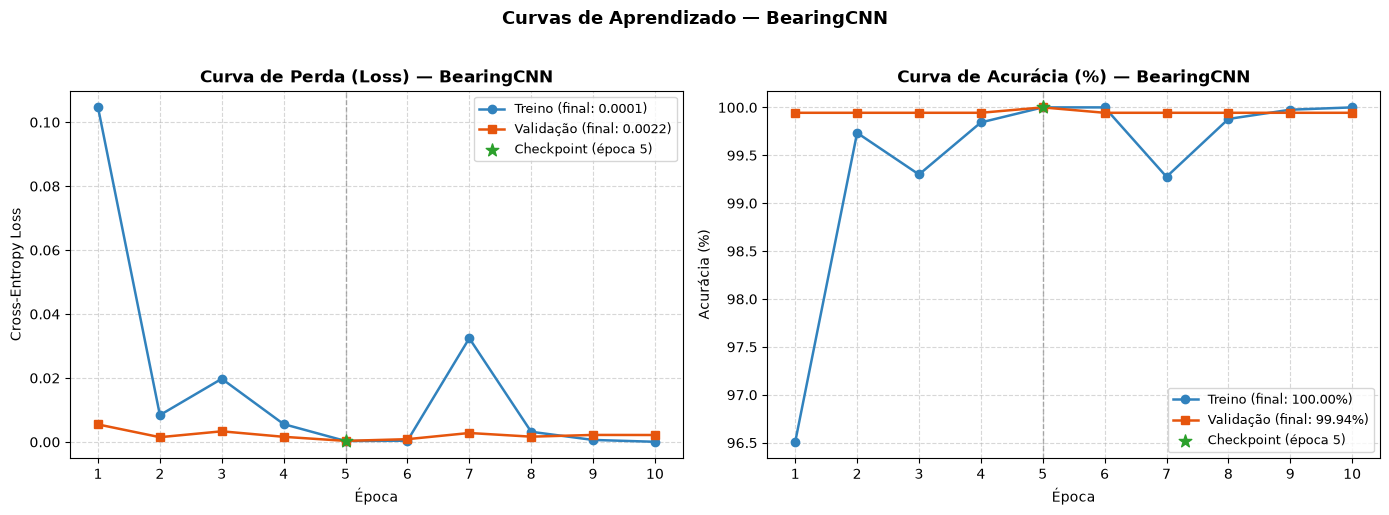

In [3]:
plot_training_curves(res["history"], "BearingCNN")

## 4. Relatório de Classificação Detalhado

In [4]:
print('================================================================================')
print(' RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (BEARING CNN) ')
print('================================================================================')
print(classification_report(res['test_labels'], res['test_preds'], target_names=res['classes'], digits=4))

 RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (BEARING CNN) 
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



## 5. Matriz de Confusão

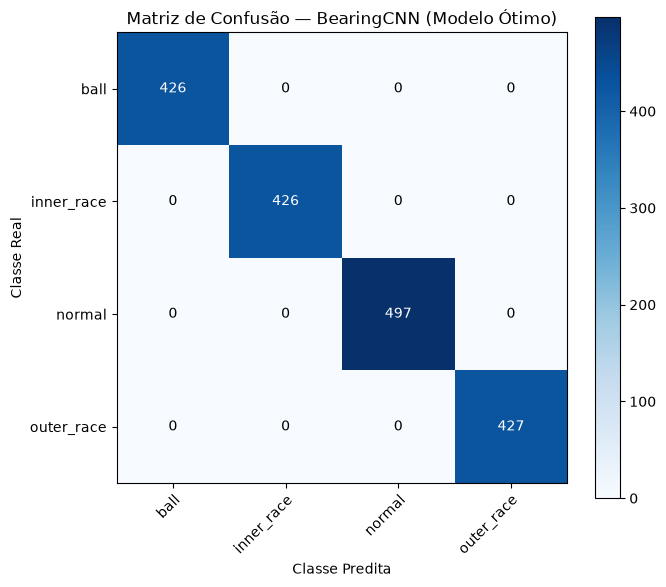

In [ ]:
# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res, 'Modelo Treinado do Zero')
